In [1]:
# Standard Library
import os
import math
import re
import random
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

# Third Party
import numpy as np
import cv2
from PIL import Image
from pdf2image import convert_from_path
import pytesseract

In [2]:
# ===============================
# Dataclasses
# ===============================

@dataclass
class PageImage:
    image: np.ndarray
    page_number: int
    width: int
    height: int
    dpi: int


@dataclass
class Document:
    pages: List[PageImage]
    source_type: str  # "pdf" or "image"
    dpi: int
    total_pages: int

In [3]:
# ===============================
# Helper Functions
# ===============================

from os import path


SUPPORTED_IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}
SUPPORTED_PDF_EXTENSIONS = {".pdf"}
CURRENT_DIR = Path(os.getcwd()) 
BASE_DIR = CURRENT_DIR.parent.parent


def _validate_file(path: Path):
    
    print(f"[INFO] Validating file: {path}")
    if not path.exists():
        raise FileNotFoundError(f"[ERROR] File does not exist: {path}")
    if not path.is_file():
        raise ValueError(f"[ERROR] Path is not a file: {path}")


def _get_file_type(path: Path) -> str:
    suffix = path.suffix.lower()
    if suffix in SUPPORTED_PDF_EXTENSIONS:
        return "pdf"
    elif suffix in SUPPORTED_IMAGE_EXTENSIONS:
        return "image"
    else:
        raise ValueError(f"[ERROR] Unsupported file type: {suffix}")


def _pil_to_numpy_rgb(pil_image: Image.Image) -> np.ndarray:
    """Convert PIL image to RGB NumPy array safely."""
    if pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")
    return np.array(pil_image)


def _load_image_file(path: Path, default_dpi: int = 300) -> PageImage:
    """Load a single image file safely and normalize to RGB."""

    print(f"[INFO] Loading image file: {path.name}")

    try:
        pil_img = Image.open(path)
        pil_img.verify()  # Validate integrity
        pil_img = Image.open(path)  # Re-open after verify
    except Exception as e:
        raise ValueError(f"[ERROR] Corrupted or unreadable image file: {e}")

    np_img = _pil_to_numpy_rgb(pil_img)
    height, width = np_img.shape[:2]

    return PageImage(
        image=np_img,
        page_number=1,
        width=width,
        height=height,
        dpi=default_dpi
    )


def _convert_pdf_to_pages(path: Path, dpi: int = 400) -> List[PageImage]:
    """Convert PDF pages to high-DPI RGB images."""

    print(f"[INFO] Converting PDF to images at {dpi} DPI: {path.name}")

    try:
        pil_pages = convert_from_path(str(path), dpi=dpi)
    except Exception as e:
        raise RuntimeError(f"[ERROR] Failed to convert PDF: {e}")

    pages = []

    for idx, pil_page in enumerate(pil_pages):
        np_img = _pil_to_numpy_rgb(pil_page)
        height, width = np_img.shape[:2]

        pages.append(
            PageImage(
                image=np_img,
                page_number=idx + 1,
                width=width,
                height=height,
                dpi=dpi
            )
        )

    print(f"[INFO] PDF converted successfully. Total pages: {len(pages)}")

    return pages

In [4]:
# ===============================
# Main Ingestion Function
# ===============================

def ingest_document(file_path: str, pdf_dpi: int = 400) -> Document:
    """
    Ingest a PDF or image file and return a structured Document object.

    Parameters:
        file_path (str): Path to PDF or image
        pdf_dpi (int): DPI for PDF conversion (default 400)

    Returns:
        Document
    """

    path = Path(file_path)
    final_path = BASE_DIR / path

    print(f"[INFO] Starting ingestion: {final_path.name}")

    _validate_file(final_path)
    file_type = _get_file_type(final_path)

    if file_type == "pdf":
        pages = _convert_pdf_to_pages(final_path, dpi=pdf_dpi)
        source_dpi = pdf_dpi

    elif file_type == "image":
        page = _load_image_file(final_path)
        pages = [page]
        source_dpi = page.dpi

    else:
        raise RuntimeError("[ERROR] Unexpected file type encountered.")

    document = Document(
        pages=pages,
        source_type=file_type,
        dpi=source_dpi,
        total_pages=len(pages)
    )

    print(f"[SUCCESS] Ingestion complete.")
    print(f"          Source type : {document.source_type}")
    print(f"          Total pages : {document.total_pages}")
    print(f"          DPI         : {document.dpi}")

    return document

In [5]:
# ===============================
# Example Usage
# ===============================

# Replace with your test file path
file_path = "Case Sample\\Case_Sample(1).jpeg"

try:
    document = ingest_document(file_path)

    # Access first page
    first_page = document.pages[0]

    print("\n--- First Page Info ---")
    print("Page number:", first_page.page_number)
    print("Width:", first_page.width)
    print("Height:", first_page.height)
    print("DPI:", first_page.dpi)

except Exception as e:
    print(str(e))

[INFO] Starting ingestion: Case_Sample(1).jpeg
[INFO] Validating file: e:\Anaconda3\envs\Judge-Assistant\Case Sample\Case_Sample(1).jpeg
[INFO] Loading image file: Case_Sample(1).jpeg
[SUCCESS] Ingestion complete.
          Source type : image
          Total pages : 1
          DPI         : 300

--- First Page Info ---
Page number: 1
Width: 899
Height: 1599
DPI: 300


In [6]:
# ==========================================
# Quality Metric Utilities
# ==========================================

def compute_mean_intensity(image_rgb: np.ndarray) -> float:
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return float(np.mean(gray))


def compute_contrast_estimate(image_rgb: np.ndarray) -> float:
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return float(np.std(gray))


def compute_noise_estimate(image_rgb: np.ndarray) -> float:
    """
    Estimate noise via Laplacian variance.
    Higher value may indicate noise or fine details.
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    return float(lap.var())

In [7]:
# ==========================================
# Image Restoration Pipeline
# ==========================================

class ImageRestorationPipeline:

    def __init__(
        self,
        denoise_strength: int = 10,
        clahe_clip_limit: float = 2.0,
        clahe_tile_grid_size: Tuple[int, int] = (8, 8),
        morph_kernel_size: int = 2,
        illumination_blur_kernel: int = 51
    ):
        """
        Parameters are intentionally conservative to avoid
        destroying Arabic diacritics or thin handwriting.
        """

        self.denoise_strength = denoise_strength
        self.clahe_clip_limit = clahe_clip_limit
        self.clahe_tile_grid_size = clahe_tile_grid_size
        self.morph_kernel_size = morph_kernel_size
        self.illumination_blur_kernel = illumination_blur_kernel

    # --------------------------------------
    # Step A — Denoising
    # --------------------------------------
    def _denoise(self, image_rgb: np.ndarray) -> np.ndarray:
        print("   → Applying denoising...")
        denoised = cv2.fastNlMeansDenoisingColored(
            image_rgb,
            None,
            self.denoise_strength,
            self.denoise_strength,
            7,
            21
        )
        return denoised

    # --------------------------------------
    # Step B — Contrast Enhancement (CLAHE)
    # --------------------------------------
    def _enhance_contrast(self, image_rgb: np.ndarray) -> np.ndarray:
        print("   → Enhancing contrast (CLAHE)...")

        lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=self.clahe_clip_limit,
            tileGridSize=self.clahe_tile_grid_size
        )

        l_enhanced = clahe.apply(l)
        merged = cv2.merge((l_enhanced, a, b))
        enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

        return enhanced_rgb

    # --------------------------------------
    # Step C — Repair Broken Strokes
    # --------------------------------------
    def _repair_strokes(self, image_rgb: np.ndarray) -> np.ndarray:
        print("   → Repairing intermittent strokes...")

        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        # Light morphological closing
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (self.morph_kernel_size, self.morph_kernel_size)
        )

        closed = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

        # Blend softly to avoid thickening text
        blended = cv2.addWeighted(gray, 0.7, closed, 0.3, 0)

        repaired_rgb = cv2.cvtColor(blended, cv2.COLOR_GRAY2RGB)

        return repaired_rgb

    # --------------------------------------
    # Step D — Illumination Normalization
    # --------------------------------------
    def _normalize_background(self, image_rgb: np.ndarray) -> np.ndarray:
        print("   → Normalizing background illumination...")

        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        # Estimate background using large Gaussian blur
        blur = cv2.GaussianBlur(
            gray,
            (self.illumination_blur_kernel, self.illumination_blur_kernel),
            0
        )

        # Avoid divide-by-zero
        blur = blur.astype(np.float32) + 1e-5
        normalized = gray.astype(np.float32) / blur
        normalized = cv2.normalize(normalized, None, 0, 255, cv2.NORM_MINMAX)
        normalized = normalized.astype(np.uint8)

        normalized_rgb = cv2.cvtColor(normalized, cv2.COLOR_GRAY2RGB)

        return normalized_rgb

    # --------------------------------------
    # Full Pipeline
    # --------------------------------------
    def process_page(self, image_rgb: np.ndarray) -> np.ndarray:
        """
        Full restoration pipeline for a single page.
        """

        step1 = self._denoise(image_rgb)
        step2 = self._enhance_contrast(step1)
        step3 = self._repair_strokes(step2)
        step4 = self._normalize_background(step3)

        return step4

In [8]:
# ==========================================
# Restore Entire Document
# ==========================================

def restore_document(document):
    """
    Accepts a Document object from Layer 1.
    Returns a NEW Document object with restored images.
    Does NOT mutate original.
    """

    print("\n[INFO] Starting restoration pipeline...\n")

    pipeline = ImageRestorationPipeline()

    restored_pages = []

    for page in document.pages:
        print(f"[PAGE {page.page_number}]")

        original_image = page.image

        # --- Metrics Before ---
        mean_before = compute_mean_intensity(original_image)
        contrast_before = compute_contrast_estimate(original_image)
        noise_before = compute_noise_estimate(original_image)

        print(f"   Before → Mean: {mean_before:.2f} | "
              f"Contrast: {contrast_before:.2f} | "
              f"Noise: {noise_before:.2f}")

        # Process
        restored_image = pipeline.process_page(original_image)

        # --- Metrics After ---
        mean_after = compute_mean_intensity(restored_image)
        contrast_after = compute_contrast_estimate(restored_image)
        noise_after = compute_noise_estimate(restored_image)

        print(f"   After  → Mean: {mean_after:.2f} | "
              f"Contrast: {contrast_after:.2f} | "
              f"Noise: {noise_after:.2f}\n")

        restored_pages.append(
            type(page)(
                image=restored_image,
                page_number=page.page_number,
                width=page.width,
                height=page.height,
                dpi=page.dpi
            )
        )

    restored_document = type(document)(
        pages=restored_pages,
        source_type=document.source_type,
        dpi=document.dpi,
        total_pages=document.total_pages
    )

    print("[SUCCESS] Document restoration complete.\n")

    return restored_document

In [9]:
# ==========================================
# Example Usage
# ==========================================

# Assume 'document' is output from Layer 1
# document = ingest_document("sample.pdf")

restored_document = restore_document(document)

# Access restored page
restored_page_1 = restored_document.pages[0]


[INFO] Starting restoration pipeline...

[PAGE 1]
   Before → Mean: 161.82 | Contrast: 52.97 | Noise: 656.85
   → Applying denoising...
   → Enhancing contrast (CLAHE)...
   → Repairing intermittent strokes...
   → Normalizing background illumination...
   After  → Mean: 116.72 | Contrast: 16.28 | Noise: 234.60

[SUCCESS] Document restoration complete.



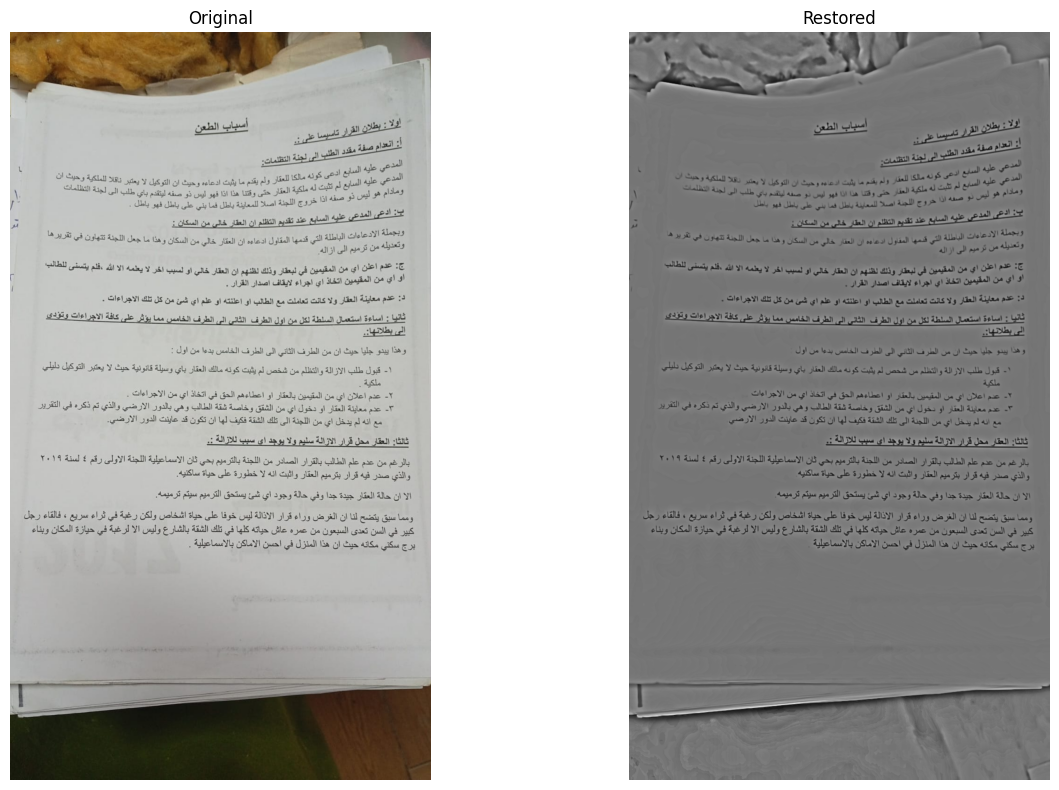

In [10]:
# ==========================================
# Debug Visualization (Original vs Restored)
# ==========================================

import matplotlib.pyplot as plt

def show_before_after(original_page, restored_page, figsize=(14, 8)):
    """
    Displays original and restored images side by side.
    """

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].imshow(original_page.image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(restored_page.image)
    axes[1].set_title("Restored")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# ---- Usage ----

original_page_1 = document.pages[0]
restored_page_1 = restored_document.pages[0]

show_before_after(original_page_1, restored_page_1)

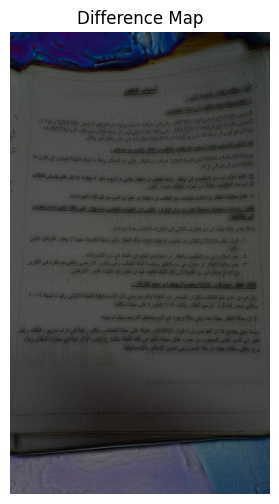

In [11]:
def show_difference(original_page, restored_page):
    diff = cv2.absdiff(original_page.image, restored_page.image)

    plt.figure(figsize=(6, 6))
    plt.imshow(diff)
    plt.title("Difference Map")
    plt.axis("off")
    plt.show()

show_difference(original_page_1, restored_page_1)

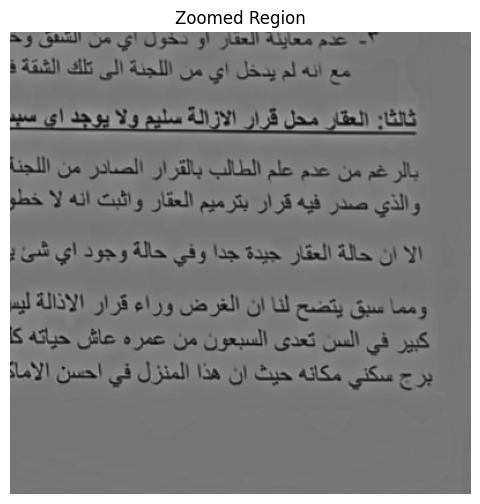

In [12]:
plt.figure(figsize=(6,6))
plt.imshow(restored_page_1.image[800:1200, 500:900])
plt.axis("off")
plt.title("Zoomed Region")
plt.show()

In [13]:
# ==========================================
# Structured Output Dataclasses
# ==========================================

@dataclass
class Region:
    bbox: Tuple[int, int, int, int]  # (x, y, w, h)
    region_type: str                 # "printed" or "handwritten"
    confidence: float
    cropped_image: np.ndarray


@dataclass
class StructuredPage:
    page_number: int
    regions: List[Region]


@dataclass
class StructuredDocument:
    pages: List[StructuredPage]

In [14]:
# ==========================================
# Feature Extraction Utilities
# ==========================================

def compute_entropy(gray: np.ndarray) -> float:
    hist = cv2.calcHist([gray], [0], None, [256], [0,256])
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return float(-np.sum(hist * np.log2(hist)))


def stroke_width_variation(gray: np.ndarray) -> float:
    edges = cv2.Canny(gray, 50, 150)
    dist = cv2.distanceTransform(255 - edges, cv2.DIST_L2, 3)
    return float(np.std(dist))


def edge_density(gray: np.ndarray) -> float:
    edges = cv2.Canny(gray, 50, 150)
    return float(np.sum(edges > 0) / edges.size)


def connected_component_irregularity(gray: np.ndarray) -> float:
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh)

    if num_labels <= 1:
        return 0.0

    areas = stats[1:, cv2.CC_STAT_AREA]
    return float(np.std(areas) / (np.mean(areas) + 1e-5))

In [15]:
# ==========================================
# Layout Analyzer
# ==========================================

class LayoutAnalyzer:

    def __init__(self, min_region_area: int = 2000):
        self.min_region_area = min_region_area

    # --------------------------------------
    # Step 1 — Detect Text Regions
    # --------------------------------------
    def _detect_text_regions(self, image_rgb: np.ndarray):

        print("   → Detecting text regions...")

        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        # 1. Detect page boundary to filter out noise outside the paper
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        page_contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if page_contours:
            main_page_cnt = max(page_contours, key=cv2.contourArea)
            px, py, pw, ph = cv2.boundingRect(main_page_cnt)
            # Define an inner boundary to ignore edge noise
            margin = 20
            page_roi = (px + margin, py + margin, pw - 2*margin, ph - 2*margin)
        else:
            page_roi = (0, 0, gray.shape[1], gray.shape[0])

        # 2. Text detection
        binary = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_MEAN_C,
            cv2.THRESH_BINARY_INV,
            31, 10
        )

        # Morphological grouping (horizontal emphasis)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
        grouped = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(
            grouped,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        regions = []

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            area = w * h

            if area > self.min_region_area:
                # Ensure the region center is within the page boundary
                cx, cy = x + w//2, y + h//2
                if (page_roi[0] <= cx <= page_roi[0] + page_roi[2] and
                    page_roi[1] <= cy <= page_roi[1] + page_roi[3]):
                    regions.append((x, y, w, h))

        return regions

    # --------------------------------------
    # Step 2 — Extract Features
    # --------------------------------------
    def _extract_region_features(self, region_img: np.ndarray):

        gray = cv2.cvtColor(region_img, cv2.COLOR_RGB2GRAY)

        features = {
            "entropy": compute_entropy(gray),
            "stroke_var": stroke_width_variation(gray),
            "edge_density": edge_density(gray),
            "cc_irregularity": connected_component_irregularity(gray),
        }

        return features

    # --------------------------------------
    # Step 3 — Rule-Based Classification
    # --------------------------------------
    def _classify_region(self, features: dict):

        score = 0

        # Handwriting indicators
        if features["stroke_var"] > 3.0:
            score += 1
        if features["cc_irregularity"] > 1.0:
            score += 1
        if features["entropy"] > 4.5:
            score += 1

        if features["edge_density"] > 0.08:
            score += 0.5

        # Decision
        if score >= 2:
            return "handwritten", min(score / 3.5, 1.0)
        else:
            return "printed", 1.0 - min(score / 3.5, 1.0)

    # --------------------------------------
    # Step 4 — Arabic Reading Order
    # --------------------------------------
    def _sort_reading_order(self, regions: List[Tuple[int,int,int,int]]):

        # Sort top-to-bottom first
        regions_sorted = sorted(regions, key=lambda r: r[1])

        # Within same horizontal band, sort right-to-left
        final_sorted = []

        band_threshold = 50
        current_band = []
        current_y = None

        for r in regions_sorted:
            if current_y is None:
                current_y = r[1]

            if abs(r[1] - current_y) < band_threshold:
                current_band.append(r)
            else:
                # Sort band right-to-left
                current_band.sort(key=lambda x: -x[0])
                final_sorted.extend(current_band)

                current_band = [r]
                current_y = r[1]

        if current_band:
            current_band.sort(key=lambda x: -x[0])
            final_sorted.extend(current_band)

        return final_sorted

    # --------------------------------------
    # Full Page Analysis
    # --------------------------------------
    def analyze_page(self, image_rgb: np.ndarray):

        detected_regions = self._detect_text_regions(image_rgb)
        ordered_regions = self._sort_reading_order(detected_regions)

        structured_regions = []

        for bbox in ordered_regions:

            x, y, w, h = bbox
            cropped = image_rgb[y:y+h, x:x+w]

            features = self._extract_region_features(cropped)
            region_type, confidence = self._classify_region(features)

            structured_regions.append(
                Region(
                    bbox=bbox,
                    region_type=region_type,
                    confidence=float(confidence),
                    cropped_image=cropped
                )
            )

        return structured_regions

In [16]:
# ==========================================
# Analyze Entire Document
# ==========================================

def analyze_layout(document):

    print("\n[INFO] Starting layout analysis...\n")

    analyzer = LayoutAnalyzer()
    structured_pages = []

    for page in document.pages:

        print(f"[PAGE {page.page_number}]")

        regions = analyzer.analyze_page(page.image)

        print(f"   → Regions detected: {len(regions)}\n")

        structured_pages.append(
            StructuredPage(
                page_number=page.page_number,
                regions=regions
            )
        )

    print("[SUCCESS] Layout analysis complete.\n")

    return StructuredDocument(pages=structured_pages)

In [17]:
# ==========================================
# Visualization Helper
# ==========================================

import matplotlib.pyplot as plt

def visualize_regions(page_image, structured_page):

    img_copy = page_image.copy()

    for region in structured_page.regions:
        x, y, w, h = region.bbox

        color = (0,255,0) if region.region_type == "printed" else (255,0,0)

        cv2.rectangle(img_copy, (x,y), (x+w, y+h), color, 3)

    plt.figure(figsize=(10,14))
    plt.imshow(img_copy)
    plt.axis("off")
    plt.title("Green = Printed | Red = Handwritten")
    plt.show()


[INFO] Starting layout analysis...

[PAGE 1]
   → Detecting text regions...
   → Regions detected: 37

[SUCCESS] Layout analysis complete.



e:\Anaconda3\envs\ai-judge\Lib\site-packages\numpy\_core\_methods.py:171: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


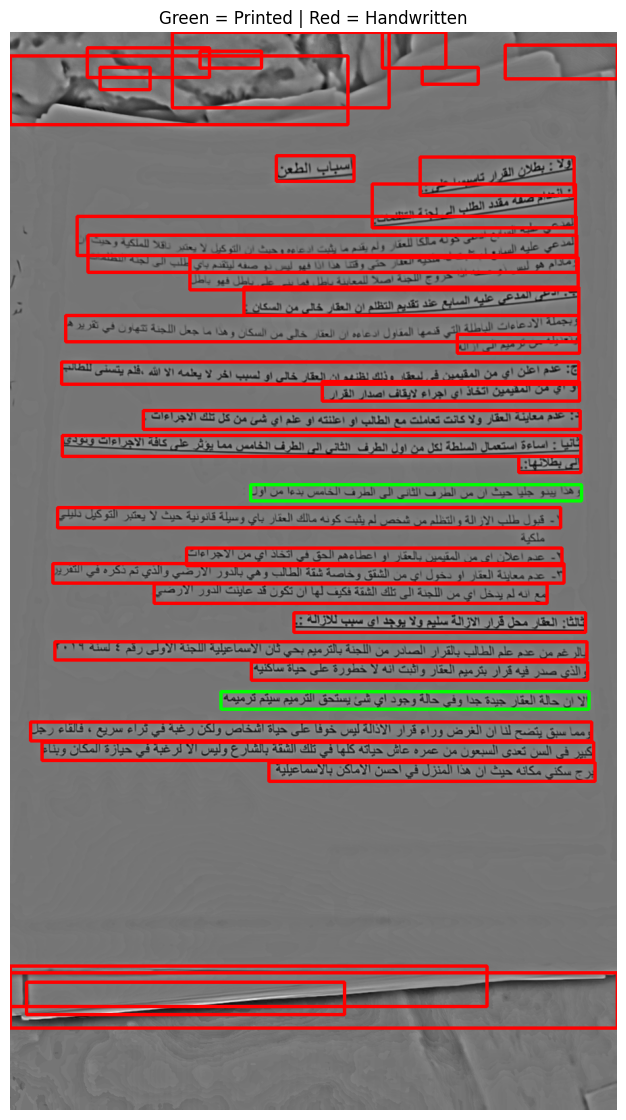

In [18]:
# Assume restored_document from Layer 2

structured_document = analyze_layout(restored_document)

first_structured_page = structured_document.pages[0]

visualize_regions(
    restored_document.pages[0].image,
    first_structured_page
)

In [19]:
# ==========================================
# OCR Output Dataclasses
# ==========================================

@dataclass
class OCRRegion:
    bbox: Tuple[int, int, int, int]
    region_type: str
    layout_confidence: float
    ocr_text: str
    ocr_confidence: float
    word_level_data: Optional[List[dict]]
    raw_engine_output: Optional[dict]


@dataclass
class OCRPage:
    page_number: int
    regions: List[OCRRegion]


@dataclass
class OCRDocument:
    pages: List[OCRPage]

In [20]:
# ==========================================
# Region-Aware OCR Engine
# ==========================================

class RegionAwareOCR:

    def __init__(self):
        # Arabic configuration
        self.printed_config = "--oem 1 --psm 6 -l ara"
        self.handwritten_config = "--oem 1 --psm 7 -l ara"

    # --------------------------------------
    # Printed OCR
    # --------------------------------------
    def _ocr_printed(self, image_rgb):

        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        data = pytesseract.image_to_data(
            gray,
            config=self.printed_config,
            output_type=pytesseract.Output.DICT
        )

        text = " ".join([w for w in data["text"] if w.strip() != ""])
        return text, data

    # --------------------------------------
    # Handwritten OCR
    # --------------------------------------
    def _ocr_handwritten(self, image_rgb):

        # Light preprocessing only
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        data = pytesseract.image_to_data(
            gray,
            config=self.handwritten_config,
            output_type=pytesseract.Output.DICT
        )

        text = " ".join([w for w in data["text"] if w.strip() != ""])
        return text, data

    # --------------------------------------
    # Postprocessing
    # --------------------------------------
    def _postprocess_text(self, text: str):

        text = re.sub(r"\s+", " ", text)
        text = text.strip()

        return text

    # --------------------------------------
    # Arabic Dominance Check
    # --------------------------------------
    def _arabic_ratio(self, text: str):

        arabic_chars = re.findall(r"[\u0600-\u06FF]", text)
        if len(text) == 0:
            return 0
        return len(arabic_chars) / len(text)

    # --------------------------------------
    # Region Confidence Computation
    # --------------------------------------
    def _compute_region_confidence(self, text, word_data):

        confidences = []

        for conf in word_data["conf"]:
            try:
                conf = float(conf)
                if conf > 0:
                    confidences.append(conf)
            except:
                continue

        if not confidences:
            base_conf = 0.0
        else:
            base_conf = sum(confidences) / len(confidences)

        # Penalize short output
        if len(text) < 3:
            base_conf *= 0.5

        # Penalize low Arabic ratio
        if self._arabic_ratio(text) < 0.4:
            base_conf *= 0.6

        # Penalize symbol-heavy text
        symbol_ratio = len(re.findall(r"[^\w\s\u0600-\u06FF]", text)) / (len(text) + 1e-5)
        if symbol_ratio > 0.3:
            base_conf *= 0.6

        return min(base_conf / 100.0, 1.0)

    # --------------------------------------
    # Process Single Region
    # --------------------------------------
    def process_region(self, region):

        if region.region_type == "printed":
            text, raw_data = self._ocr_printed(region.cropped_image)
        else:
            text, raw_data = self._ocr_handwritten(region.cropped_image)

        text = self._postprocess_text(text)

        confidence = self._compute_region_confidence(text, raw_data)

        return OCRRegion(
            bbox=region.bbox,
            region_type=region.region_type,
            layout_confidence=region.confidence,
            ocr_text=text,
            ocr_confidence=float(confidence),
            word_level_data=raw_data,
            raw_engine_output=raw_data
        )

In [21]:
# ==========================================
# Run OCR on StructuredDocument
# ==========================================

def run_ocr(structured_document):

    print("\n[INFO] Starting Region-Aware OCR...\n")

    ocr_engine = RegionAwareOCR()
    ocr_pages = []

    for page in structured_document.pages:

        print(f"[PAGE {page.page_number}]")

        ocr_regions = []

        for idx, region in enumerate(page.regions):

            print(f"   → Processing region {idx+1} ({region.region_type})")

            ocr_region = ocr_engine.process_region(region)

            print(f"      OCR Confidence: {ocr_region.ocr_confidence:.2f}")

            ocr_regions.append(ocr_region)

        ocr_pages.append(
            OCRPage(
                page_number=page.page_number,
                regions=ocr_regions
            )
        )

    print("\n[SUCCESS] OCR completed.\n")

    return OCRDocument(pages=ocr_pages)

In [22]:
# Assume structured_document from Layer 3

ocr_document = run_ocr(structured_document)

# Print low-confidence regions for debugging
for page in ocr_document.pages:
    for region in page.regions:
        if region.ocr_confidence < 0.4:
            print(f"\n⚠ Low Confidence Region (Page {page.page_number})")
            print("Type:", region.region_type)
            print("Text:", region.ocr_text)
            print("Confidence:", region.ocr_confidence)


[INFO] Starting Region-Aware OCR...

[PAGE 1]
   → Processing region 1 (handwritten)
      OCR Confidence: 0.00
   → Processing region 2 (handwritten)
      OCR Confidence: 0.26
   → Processing region 3 (handwritten)
      OCR Confidence: 0.58
   → Processing region 4 (handwritten)
      OCR Confidence: 0.00
   → Processing region 5 (handwritten)
      OCR Confidence: 0.00
   → Processing region 6 (handwritten)
      OCR Confidence: 0.00
   → Processing region 7 (handwritten)
      OCR Confidence: 0.35
   → Processing region 8 (handwritten)
      OCR Confidence: 0.03
   → Processing region 9 (handwritten)
      OCR Confidence: 0.00
   → Processing region 10 (handwritten)
      OCR Confidence: 0.00
   → Processing region 11 (handwritten)
      OCR Confidence: 0.00
   → Processing region 12 (handwritten)
      OCR Confidence: 0.00
   → Processing region 13 (handwritten)
      OCR Confidence: 0.00
   → Processing region 14 (handwritten)
      OCR Confidence: 0.00
   → Processing region 1

In [23]:
# ==========================================
# Reconstructed Document Dataclasses
# ==========================================

@dataclass
class CleanRegion:
    bbox: Tuple[int, int, int, int]
    region_type: str
    cleaned_text: str
    original_text: str
    final_confidence: float

@dataclass
class ReconstructedPage:
    page_number: int
    reconstructed_text: str
    regions: List[CleanRegion]

@dataclass
class ReconstructedDocument:
    pages: List[ReconstructedPage]
    full_text: str
    metadata: dict

In [24]:
# ==========================================
# Normalization & Cleaning Utilities
# ==========================================

def normalize_arabic(text: str) -> str:
    # Normalize Alef variants
    text = re.sub(r'[إأآ]', 'ا', text)
    # Normalize Ya
    text = re.sub(r'ى', 'ي', text)
    # Normalize Ta marbuta
    text = re.sub(r'ة', 'ه', text)
    return text

def remove_duplicate_chars(text: str) -> str:
    return re.sub(r'(.)\1{2,}', r'\1', text)

def clean_text(text: str) -> str:
    text = text.strip()
    text = normalize_arabic(text)
    text = remove_duplicate_chars(text)
    # Remove excessive punctuation (but keep meaningful)
    text = re.sub(r'[\s]{2,}', ' ', text)
    text = re.sub(r'[^\w\s\u0600-\u06FF.,:؛؟\-]', '', text)
    return text

In [25]:
# ==========================================
# TextReconstructor
# ==========================================

class TextReconstructor:

    def __init__(self):
        pass

    # --------------------------------------
    # Clean region text
    # --------------------------------------
    def _clean_text(self, text: str) -> str:
        return clean_text(text)

    # --------------------------------------
    # Refine region confidence
    # --------------------------------------
    def _refine_confidence(self, layout_conf: float, ocr_conf: float, text: str) -> float:
        conf = layout_conf * 0.4 + ocr_conf * 0.6
        if len(text) < 3:
            conf *= 0.5
        symbol_ratio = len(re.findall(r'[^\w\s\u0600-\u06FF]', text)) / (len(text) + 1e-5)
        if symbol_ratio > 0.3:
            conf *= 0.6
        return min(conf, 1.0)

    # --------------------------------------
    # Merge adjacent printed regions (paragraphs)
    # --------------------------------------
    def _merge_regions(self, regions: List[CleanRegion]) -> List[CleanRegion]:
        merged = []
        buffer = []
        for region in regions:
            if region.region_type == "printed":
                buffer.append(region)
            else:
                if buffer:
                    merged_text = "\n".join([r.cleaned_text for r in buffer])
                    merged_conf = sum([r.final_confidence for r in buffer]) / len(buffer)
                    merged_bbox = buffer[0].bbox
                    merged.append(CleanRegion(
                        bbox=merged_bbox,
                        region_type="printed",
                        cleaned_text=merged_text,
                        original_text="; ".join([r.original_text for r in buffer]),
                        final_confidence=merged_conf
                    ))
                    buffer = []
                merged.append(region)
        if buffer:
            merged_text = "\n".join([r.cleaned_text for r in buffer])
            merged_conf = sum([r.final_confidence for r in buffer]) / len(buffer)
            merged_bbox = buffer[0].bbox
            merged.append(CleanRegion(
                bbox=merged_bbox,
                region_type="printed",
                cleaned_text=merged_text,
                original_text="; ".join([r.original_text for r in buffer]),
                final_confidence=merged_conf
            ))
        return merged

    # --------------------------------------
    # Reconstruct a single page
    # --------------------------------------
    def _reconstruct_page(self, page) -> ReconstructedPage:
        clean_regions = []

        for region in page.regions:
            cleaned = self._clean_text(region.ocr_text)
            final_conf = self._refine_confidence(region.layout_confidence, region.ocr_confidence, cleaned)
            clean_regions.append(CleanRegion(
                bbox=region.bbox,
                region_type=region.region_type,
                cleaned_text=cleaned,
                original_text=region.ocr_text,
                final_confidence=final_conf
            ))

        merged_regions = self._merge_regions(clean_regions)

        page_text = ""
        for region in merged_regions:
            marker = "[HANDWRITTEN]" if region.region_type == "handwritten" else "[PRINTED]"
            page_text += f"{marker}\n{region.cleaned_text}\n\n"

        return ReconstructedPage(
            page_number=page.page_number,
            reconstructed_text=page_text.strip(),
            regions=merged_regions
        )

    # --------------------------------------
    # Build full document text
    # --------------------------------------
    def _build_full_text(self, pages: List[ReconstructedPage]) -> str:
        full_text = ""
        for page in pages:
            full_text += f"-------- PAGE {page.page_number} --------\n"
            full_text += page.reconstructed_text + "\n\n"
        return full_text.strip()

    # --------------------------------------
    # Main reconstruction function
    # --------------------------------------
    def reconstruct_document(self, ocr_document) -> ReconstructedDocument:
        reconstructed_pages = []

        for page in ocr_document.pages:
            reconstructed_pages.append(self._reconstruct_page(page))

        full_text = self._build_full_text(reconstructed_pages)

        num_handwritten = sum(
            len([r for r in page.regions if r.region_type == "handwritten"])
            for page in reconstructed_pages
        )
        num_printed = sum(
            len([r for r in page.regions if r.region_type == "printed"])
            for page in reconstructed_pages
        )

        avg_conf = sum(
            r.final_confidence
            for page in reconstructed_pages
            for r in page.regions
        ) / max(1, sum(len(page.regions) for page in reconstructed_pages))

        metadata = {
            "pages_count": len(reconstructed_pages),
            "handwritten_regions": num_handwritten,
            "printed_regions": num_printed,
            "avg_confidence": avg_conf
        }

        return ReconstructedDocument(
            pages=reconstructed_pages,
            full_text=full_text,
            metadata=metadata
        )

In [26]:
# Assume ocr_document from Layer 4

reconstructor = TextReconstructor()
reconstructed_doc = reconstructor.reconstruct_document(ocr_document)

# Print full text
print(reconstructed_doc.full_text)

# Print metadata
print("\nMetadata:", reconstructed_doc.metadata)

# Debug very low confidence regions
for page in reconstructed_doc.pages:
    for region in page.regions:
        if region.final_confidence < 0.4:
            print(f"\n⚠ Low confidence region on Page {page.page_number}")
            print("Type:", region.region_type)
            print("Text:", region.cleaned_text)
            print("Confidence:", region.final_confidence)

-------- PAGE 1 --------
[HANDWRITTEN]


[HANDWRITTEN]
ل

[HANDWRITTEN]
ييه 

[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]
سبي 0

[HANDWRITTEN]
مجه

[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]
وتعذيله من ترميم الي ازاله

[HANDWRITTEN]
لدعاءنا الباطله التي قدمها المقاول ادعاءه ان العقار خالي من السكان وهذا ما جعل اللجنه تتهاون في تقريرهه

[HANDWRITTEN]
اد اي من المقيمين اتخاذ اي اجراء لايقاف اصدار القرار .

[HANDWRITTEN]
: عدم اعلن اي من المقيمين في لبعقار وذلك لظنهم ان العقار خالي او لسبب اخر لا يعلمه الا الله فلم يتسني للطائم

[HANDWRITTEN]
د: عدم معاينه العقار ولا كانت تعاملت مع الطالب او اعلنته او علم اي شئ من كل تلك الاجراءات .

[HANDWRITTEN]
ثانيا : اساءه استعمال السلطه لكل من اول الطرف_الث الطرف الخامس مما يؤثر كافه الاجراءات ودود

[HANDWRITTEN]


[PRINTED]
وهذا يبنو جليا حيث ان من الطرف الثاني الي الطرف الخامس بدءا من اول

[HANDWRITTEN]
-١ قبول طلب الازاله والتظلم من شخص لم يثبت كو

In [27]:
@dataclass
class RegionAnalysis:
    region_type: str
    text: str
    inferred_issue: Optional[str]
    confidence: float

@dataclass
class LegalAnalysisPage:
    page_number: int
    summarized_text: str
    region_analysis: List[RegionAnalysis]

@dataclass
class LegalAnalysisDocument:
    pages: List[LegalAnalysisPage]
    full_summary: str
    extracted_issues: List[Dict]
    citations: List[Dict]
    metadata: Dict

In [28]:
# Simulate retrieval from a legal knowledge base
def retrieve_legal_context(text: str, max_results: int = 3) -> List[Dict]:
    # Placeholder: returns dummy citations
    citations = [{"title": f"Precedent {i+1}", "link": f"https://legal.example/case{i+1}"} 
                 for i in range(max_results)]
    return citations

# Simple summarizer placeholder
def summarize_text(text: str) -> str:
    # In production, connect to an LLM or summarization engine
    sentences = text.split(".")
    return ". ".join(sentences[:min(2, len(sentences))]).strip()

# Issue extraction placeholder
def extract_issues(text: str) -> List[Dict]:
    # Returns dummy issues with confidence
    issues = []
    for idx in range(random.randint(0, 2)):
        issues.append({
            "issue": f"Legal Issue {idx+1}",
            "confidence": round(random.uniform(0.5, 0.95), 2)
        })
    return issues

In [29]:
class LegalReasonerRAG:
    
    def __init__(self):
        pass

    # --------------------------------------
    # Retrieve context for a text block
    # --------------------------------------
    def _retrieve_legal_context(self, text: str) -> List[Dict]:
        return retrieve_legal_context(text)

    # --------------------------------------
    # Summarize a page
    # --------------------------------------
    def _summarize_page(self, page_text: str) -> str:
        return summarize_text(page_text)

    # --------------------------------------
    # Extract legal issues from text
    # --------------------------------------
    def _extract_issues(self, page_text: str) -> List[Dict]:
        return extract_issues(page_text)

    # --------------------------------------
    # Analyze regions individually
    # --------------------------------------
    def _analyze_regions(self, regions) -> List[RegionAnalysis]:
        analysis = []
        for region in regions:
            issues = self._extract_issues(region.cleaned_text)
            inferred_issue = issues[0]["issue"] if issues else None
            confidence = (region.final_confidence + (issues[0]["confidence"] if issues else 0.5)) / 2
            analysis.append(RegionAnalysis(
                region_type=region.region_type,
                text=region.cleaned_text,
                inferred_issue=inferred_issue,
                confidence=confidence
            ))
        return analysis

    # --------------------------------------
    # Aggregate metadata
    # --------------------------------------
    def _aggregate_metadata(self, pages: List[LegalAnalysisPage], citations: List[Dict]) -> Dict:
        total_pages = len(pages)
        total_regions = sum(len(p.region_analysis) for p in pages)
        return {
            "pages_count": total_pages,
            "total_regions": total_regions,
            "total_citations": len(citations)
        }

    # --------------------------------------
    # Main function: analyze_document
    # --------------------------------------
    def analyze_document(self, reconstructed_doc) -> LegalAnalysisDocument:
        pages_analysis = []
        all_citations = []
        all_issues = []

        for page in reconstructed_doc.pages:
            region_analysis = self._analyze_regions(page.regions)
            page_text = page.reconstructed_text
            summarized = self._summarize_page(page_text)
            citations = self._retrieve_legal_context(page_text)

            # Collect issues from regions
            for region in region_analysis:
                if region.inferred_issue:
                    all_issues.append({
                        "page": page.page_number,
                        "issue": region.inferred_issue,
                        "confidence": region.confidence
                    })

            all_citations.extend(citations)

            pages_analysis.append(LegalAnalysisPage(
                page_number=page.page_number,
                summarized_text=summarized,
                region_analysis=region_analysis
            ))

        full_summary = summarize_text(reconstructed_doc.full_text)
        metadata = self._aggregate_metadata(pages_analysis, all_citations)

        return LegalAnalysisDocument(
            pages=pages_analysis,
            full_summary=full_summary,
            extracted_issues=all_issues,
            citations=all_citations,
            metadata=metadata
        )

In [30]:
# Assume reconstructed_doc from Layer 5
legal_reasoner = LegalReasonerRAG()
legal_analysis_doc = legal_reasoner.analyze_document(reconstructed_doc)

# Print full summary
print("=== FULL SUMMARY ===")
print(legal_analysis_doc.full_summary)

# Print metadata
print("\n=== METADATA ===")
print(legal_analysis_doc.metadata)

# Print issues and citations
print("\n=== EXTRACTED ISSUES ===")
for issue in legal_analysis_doc.extracted_issues:
    print(issue)

print("\n=== CITATIONS ===")
for citation in legal_analysis_doc.citations:
    print(citation)

=== FULL SUMMARY ===
-------- PAGE 1 --------
[HANDWRITTEN]


[HANDWRITTEN]
ل

[HANDWRITTEN]
ييه 

[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]
سبي 0

[HANDWRITTEN]
مجه

[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]


[HANDWRITTEN]
وتعذيله من ترميم الي ازاله

[HANDWRITTEN]
لدعاءنا الباطله التي قدمها المقاول ادعاءه ان العقار خالي من السكان وهذا ما جعل اللجنه تتهاون في تقريرهه

[HANDWRITTEN]
اد اي من المقيمين اتخاذ اي اجراء لايقاف اصدار القرار . 

[HANDWRITTEN]
: عدم اعلن اي من المقيمين في لبعقار وذلك لظنهم ان العقار خالي او لسبب اخر لا يعلمه الا الله فلم يتسني للطائم

[HANDWRITTEN]
د: عدم معاينه العقار ولا كانت تعاملت مع الطالب او اعلنته او علم اي شئ من كل تلك الاجراءات

=== METADATA ===
{'pages_count': 1, 'total_regions': 37, 'total_citations': 3}

=== EXTRACTED ISSUES ===
{'page': 1, 'issue': 'Legal Issue 1', 'confidence': 0.3853928571428571}
{'page': 1, 'issue': 'Legal Issue 1', 'confidence': 0.455714285